# Sentiment Model Performance Analysis

This notebook loads the sampled sentence set, the model predictions, and the sentiment annotations from Dekker and Egberink, then calculates model performance on the annotated sentences.

In [60]:
from pathlib import Path
import json
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

def resolve_study_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "annotation" / "sentiment_model_assessment",
        cwd / "sentiment_model_assessment",
        cwd.parent / "annotation" / "sentiment_model_assessment",
        cwd.parent / "sentiment_model_assessment",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate annotation/sentiment_model_assessment from the current working directory.")


STUDY_DIR = resolve_study_dir()
PREDICTIONS_PATH = STUDY_DIR / "model_predictions_wide.csv"
MODELS_PATH = STUDY_DIR / "models.json"
DB_DIR = STUDY_DIR / "databases"


def load_model_display_names(models_path: Path) -> dict[str, str]:
    if not models_path.exists():
        return {}
    records = json.loads(models_path.read_text(encoding="utf-8"))
    return {
        str(record.get("model_slug", "")): str(record.get("display_name") or record.get("model_id") or record.get("model_slug"))
        for record in records
        if record.get("model_slug")
    }


def load_annotation_dbs(db_dir: Path) -> pd.DataFrame:
    db_files = sorted([p for p in db_dir.glob("*.db")])
    rows = []
    for db_file in db_files:
        try:
            with sqlite3.connect(db_file) as conn:
                tables = [row[0] for row in conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
        except sqlite3.DatabaseError:
            continue
        if "annotations" not in tables:
            continue
        try:
            df = pd.read_sql_query("SELECT * FROM annotations", sqlite3.connect(db_file))
        except Exception:
            continue
        if df.empty:
            continue
        df["source_db"] = db_file.name
        rows.append(df)
    if not rows:
        raise FileNotFoundError(f"No SQLite database with an 'annotations' table and data found in {db_dir}.")
    merged = pd.concat(rows, ignore_index=True)
    merged = merged.sort_values(["annotator", "sample_id", "created_at"]).drop_duplicates(
        subset=["annotator", "sample_id"], keep="last"
    )
    return merged

MODEL_DISPLAY_NAMES = load_model_display_names(MODELS_PATH)

PREDICTIONS_PATH, DB_DIR

(PosixPath('/Users/Yannick/dev/geothermal_text_mining/annotation/sentiment_model_assessment/model_predictions_wide.csv'),
 PosixPath('/Users/Yannick/dev/geothermal_text_mining/annotation/sentiment_model_assessment/databases'))

In [61]:
predictions = pd.read_csv(PREDICTIONS_PATH)
annotations = load_annotation_dbs(DB_DIR)

predictions.shape, annotations.shape

((270, 76), (300, 6))

In [62]:
annotations = annotations.sort_values(["annotator", "sample_id", "created_at"]).drop_duplicates(
    subset=["annotator", "sample_id"], keep="last"
)

merged = predictions.merge(
    annotations[["sample_id", "annotator", "gold_sentiment", "notes", "created_at"]],
    on="sample_id",
    how="inner",
)

merged[["sample_id", "annotator", "gold_sentiment", "sentence_text"]].head()

merged[["gold_sentiment", "sentence_text"]].to_csv(STUDY_DIR / "merged_annotations_predictions.csv", index=False)

In [63]:
SENTIMENTS = ["negative", "neutral", "positive"]
MODEL_COLUMNS = sorted([col for col in merged.columns if col.endswith("__sentiment")])

def display_name_for_model(model_slug: str) -> str:
    return MODEL_DISPLAY_NAMES.get(model_slug, model_slug)

def per_class_scores(df, pred_col, gold_col="gold_sentiment", labels=SENTIMENTS):
    rows = []
    for label in labels:
        tp = int(((df[pred_col] == label) & (df[gold_col] == label)).sum())
        fp = int(((df[pred_col] == label) & (df[gold_col] != label)).sum())
        fn = int(((df[pred_col] != label) & (df[gold_col] == label)).sum())
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 0.0 if (precision + recall) == 0 else 2 * precision * recall / (precision + recall)
        rows.append({
            "label": label,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": int((df[gold_col] == label).sum()),
        })
    return pd.DataFrame(rows)

def model_summary(df, pred_col, gold_col="gold_sentiment"):
    current = df.dropna(subset=[pred_col, gold_col]).copy()
    scores = per_class_scores(current, pred_col=pred_col, gold_col=gold_col)
    accuracy = float((current[pred_col] == current[gold_col]).mean()) if len(current) else 0.0
    macro_f1 = float(scores["f1"].mean()) if len(scores) else 0.0
    return {
        "n": len(current),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    }

rows = []
for annotator, group in merged.groupby("annotator"):
    for pred_col in MODEL_COLUMNS:
        summary = model_summary(group, pred_col=pred_col)
        model = pred_col.replace("__sentiment", "")
        rows.append({
            "annotator": annotator,
            "model": model,
            "model_display_name": display_name_for_model(model),
            **summary,
        })

performance = pd.DataFrame(rows).sort_values(
    ["annotator", "accuracy", "macro_f1", "model_display_name"],
    ascending=[True, False, False, True],
)
performance

,annotator,model,model_display_name,n,accuracy,macro_f1
7,Dekker,ollama_qwen2_5_7b,Ollama qwen2.5:14b,150,0.813333,0.789490
10,Dekker,tabularisai_multilingual,TabularisAI Multilingual,150,0.620000,0.457884
8,Dekker,oralunal_sentiment,oralunal Sentiment,150,0.620000,0.457884
9,Dekker,oxygene_dev_sentiment_multilingual,oxygeneDev Sentiment Multilingual,150,0.620000,0.457884
1,Dekker,bramvanroy_bert_base_dutch_cased_hebban_reviews,BramVanroy BERT Dutch Hebban,150,0.586667,0.483025
5,Dekker,bramvanroy_robbert_v2_dutch_base_hebban_reviews,BramVanroy RobBERT v2 Dutch Hebban,150,0.566667,0.399310
4,Dekker,bramvanroy_robbert_v2_dutch_base_hebban_reviews5,BramVanroy RobBERT v2 Dutch Hebban v5,150,0.493333,0.405693
6,Dekker,bramvanroy_xlm_roberta_base_hebban_reviews,BramVanroy XLM-RoBERTa base Hebban,150,0.466667,0.448675
2,Dekker,bramvanroy_bert_base_multilingual_cased_hebban...,BramVanroy BERT multilingual Hebban v5,150,0.426667,0.418282
3,Dekker,bramvanroy_bert_base_multilingual_cased_hebban...,BramVanroy BERT multilingual Hebban,150,0.426667,0.391173


## Confidence-thresholded Neutral Reclassification

This section evaluates what happens when low-confidence positive/negative predictions are remapped to neutral. The analysis compares several confidence thresholds for each model and annotator.

In [64]:
CONFIDENCE_THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


def apply_neutral_threshold(series_pred, series_conf, threshold):
    adjusted = series_pred.copy()
    low_confidence = series_conf < threshold
    low_confidence = low_confidence & series_pred.isin(["positive", "negative"])
    return adjusted.mask(low_confidence, "neutral")


def thresholded_summary(df, pred_col, conf_col, thresholds, gold_col="gold_sentiment"):
    current = df.dropna(subset=[pred_col, conf_col, gold_col]).copy()
    rows = []
    for threshold in thresholds:
        adjusted_pred = apply_neutral_threshold(current[pred_col], current[conf_col], threshold)
        accuracy = float((adjusted_pred == current[gold_col]).mean()) if len(current) else 0.0
        scores = per_class_scores(
            pd.DataFrame({pred_col: adjusted_pred, gold_col: current[gold_col]}),
            pred_col=pred_col,
            gold_col=gold_col,
        )
        rows.append(
            {
                "threshold": threshold,
                "n": len(current),
                "accuracy": accuracy,
                "macro_f1": float(scores["f1"].mean()) if len(scores) else 0.0,
                "negative_support": int((current[gold_col] == "negative").sum()),
                "neutral_support": int((current[gold_col] == "neutral").sum()),
                "positive_support": int((current[gold_col] == "positive").sum()),
            }
        )
    return pd.DataFrame(rows)


def build_threshold_analysis(merged_df):
    rows = []
    for pred_col in MODEL_COLUMNS:
        conf_col = pred_col.replace("__sentiment", "__confidence")
        if conf_col not in merged_df.columns:
            print(f"Skipping {pred_col} because {conf_col} is missing")
            continue
        model = pred_col.replace("__sentiment", "")
        result = thresholded_summary(merged_df, pred_col=pred_col, conf_col=conf_col, thresholds=CONFIDENCE_THRESHOLDS)
        result["model"] = model
        result["model_display_name"] = display_name_for_model(model)
        rows.append(result)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

threshold_results = build_threshold_analysis(merged)
threshold_results = threshold_results.sort_values(["model_display_name", "threshold"], ascending=[True, True])

best_thresholds = (
    threshold_results.sort_values(["model", "accuracy", "macro_f1"], ascending=[True, False, False])
    .groupby(["model"], as_index=False)
    .first()
)

print("Best threshold overall per model:")
display(best_thresholds)

Best threshold overall per model:


,model,threshold,n,accuracy,macro_f1,negative_support,neutral_support,positive_support,model_display_name
0,bramvanroy_bert_base_dutch_cased_hebban_reviews,0.6,300,0.546667,0.440470,77,157,66,BramVanroy BERT Dutch Hebban
1,bramvanroy_bert_base_dutch_cased_hebban_reviews5,0.4,300,0.553333,0.493337,77,157,66,BramVanroy BERT Dutch Hebban v5
2,bramvanroy_bert_base_multilingual_cased_hebban...,0.6,300,0.520000,0.396356,77,157,66,BramVanroy BERT multilingual Hebban
3,bramvanroy_bert_base_multilingual_cased_hebban...,0.7,300,0.493333,0.298930,77,157,66,BramVanroy BERT multilingual Hebban v5
4,bramvanroy_robbert_v2_dutch_base_hebban_reviews,0.1,300,0.536667,0.436935,77,157,66,BramVanroy RobBERT v2 Dutch Hebban
5,bramvanroy_robbert_v2_dutch_base_hebban_reviews5,0.7,300,0.566667,0.332032,77,157,66,BramVanroy RobBERT v2 Dutch Hebban v5
6,bramvanroy_xlm_roberta_base_hebban_reviews,0.6,300,0.570000,0.419994,77,157,66,BramVanroy XLM-RoBERTa base Hebban
7,ollama_qwen2_5_7b,0.1,300,0.803333,0.790830,77,157,66,Ollama qwen2.5:14b
8,oralunal_sentiment,0.1,300,0.580000,0.469206,77,157,66,oralunal Sentiment
9,oxygene_dev_sentiment_multilingual,0.1,300,0.580000,0.469206,77,157,66,oxygeneDev Sentiment Multilingual


## Confusion Matrix (Best Thresholds)

This section computes and plots confusion matrices using the optimized threshold for the full sentence set across all annotators.

All sentences — BramVanroy BERT Dutch Hebban (threshold=0.6)


predicted,negative,neutral,positive
gold,,,
negative,22,47,8
neutral,18,128,11
positive,3,49,14


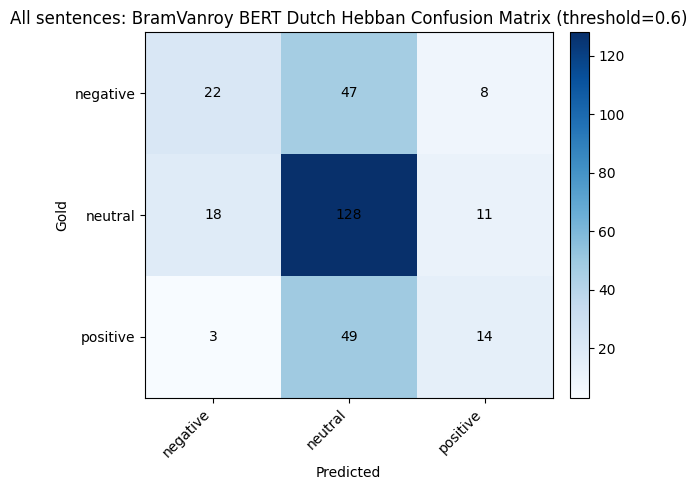

All sentences — BramVanroy BERT Dutch Hebban v5 (threshold=0.4)


predicted,negative,neutral,positive
gold,,,
negative,30,40,7
neutral,22,114,21
positive,4,40,22


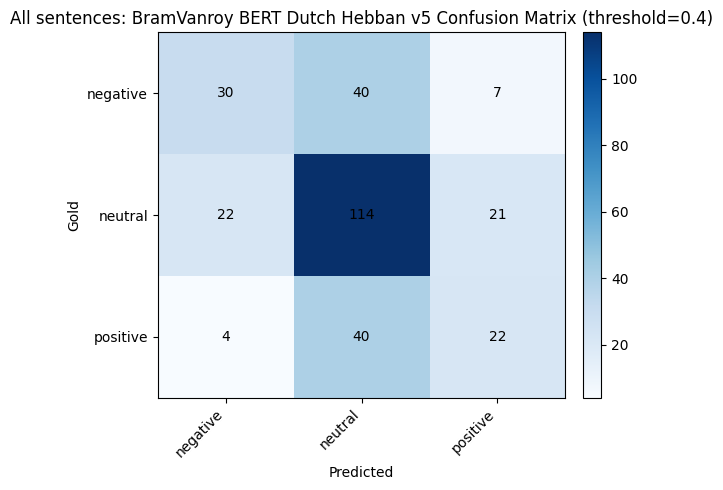

All sentences — BramVanroy BERT multilingual Hebban (threshold=0.6)


predicted,negative,neutral,positive
gold,,,
negative,26,45,6
neutral,29,123,5
positive,12,47,7


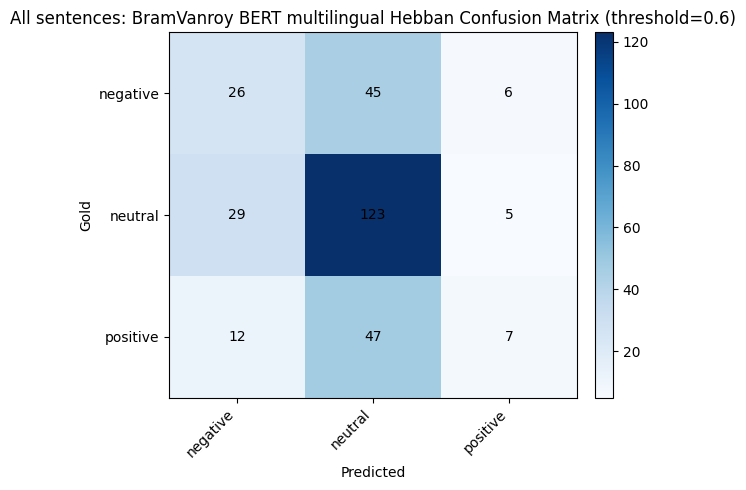

All sentences — BramVanroy BERT multilingual Hebban v5 (threshold=0.7)


predicted,negative,neutral,positive
gold,,,
negative,15,60,2
neutral,22,133,2
positive,11,55,0


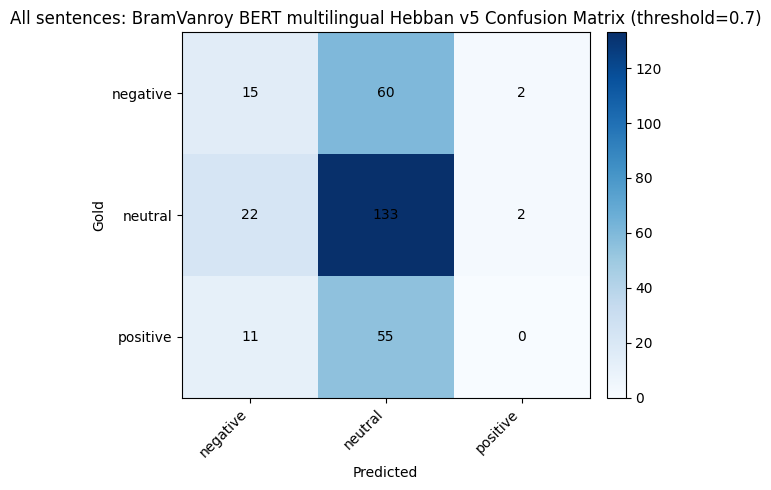

All sentences — BramVanroy RobBERT v2 Dutch Hebban (threshold=0.1)


predicted,negative,neutral,positive
gold,,,
negative,16,51,10
neutral,19,125,13
positive,2,44,20


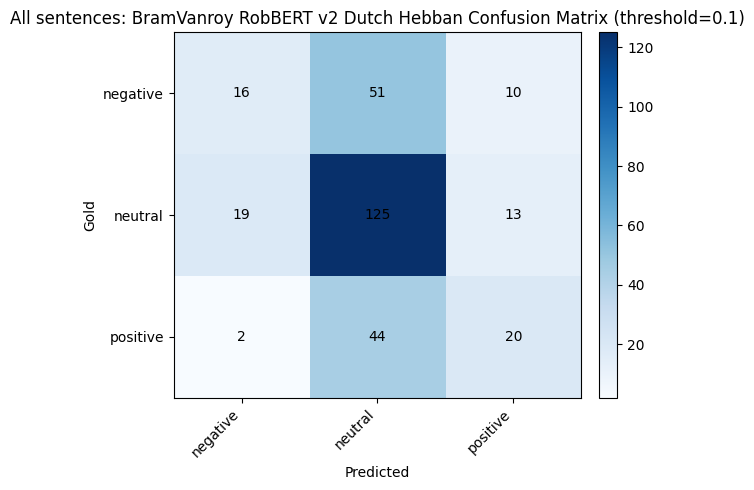

All sentences — BramVanroy RobBERT v2 Dutch Hebban v5 (threshold=0.7)


predicted,negative,neutral,positive
gold,,,
negative,13,64,0
neutral,0,157,0
positive,0,66,0


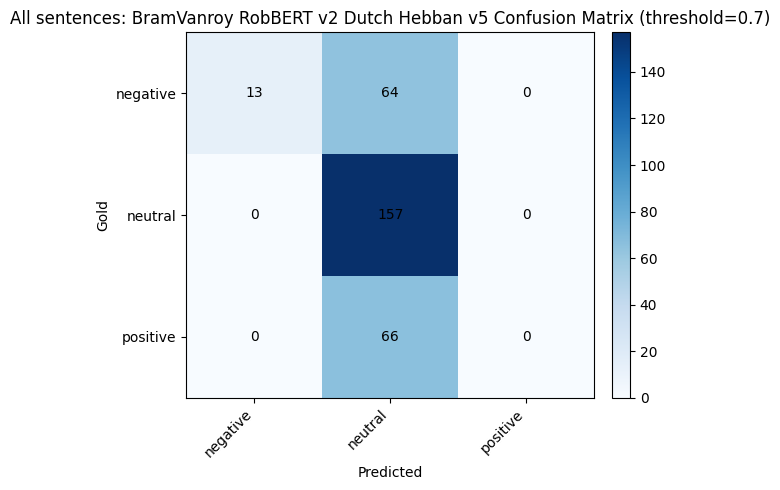

All sentences — BramVanroy XLM-RoBERTa base Hebban (threshold=0.6)


predicted,negative,neutral,positive
gold,,,
negative,15,61,1
neutral,9,145,3
positive,2,53,11


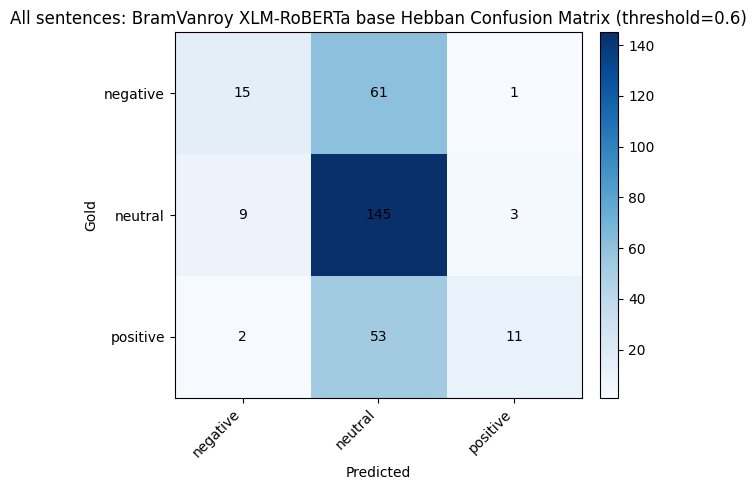

All sentences — Ollama qwen2.5:14b (threshold=0.1)


predicted,negative,neutral,positive
gold,,,
negative,65,11,1
neutral,14,131,12
positive,2,19,45


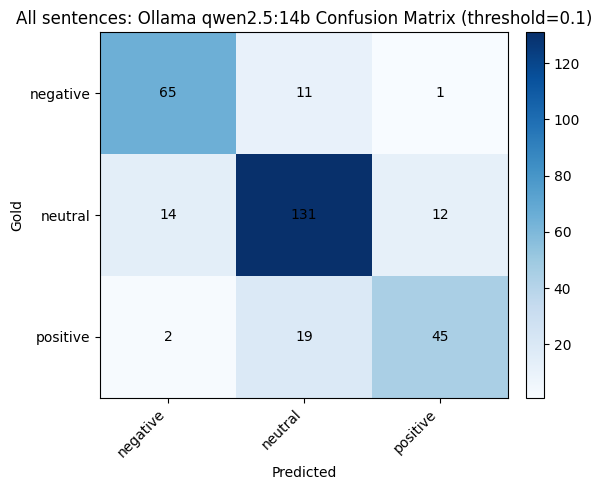

All sentences — oralunal Sentiment (threshold=0.1)


predicted,negative,neutral,positive
gold,,,
negative,26,46,5
neutral,17,135,5
positive,5,48,13


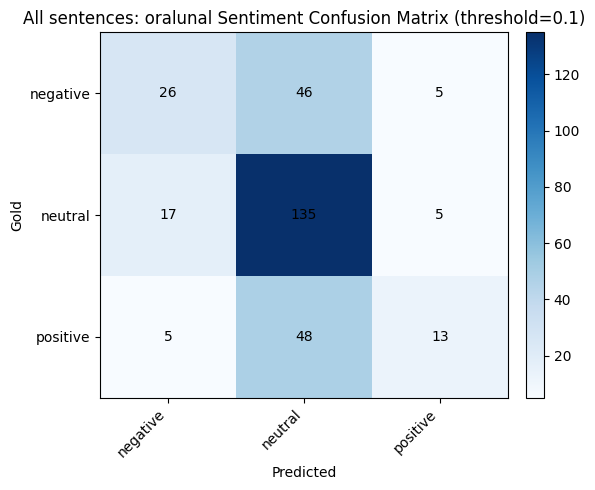

All sentences — oxygeneDev Sentiment Multilingual (threshold=0.1)


predicted,negative,neutral,positive
gold,,,
negative,26,46,5
neutral,17,135,5
positive,5,48,13


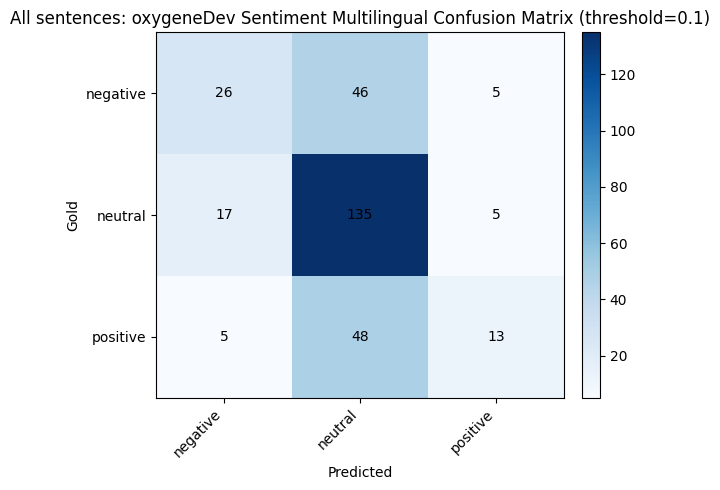

All sentences — TabularisAI Multilingual (threshold=0.1)


predicted,negative,neutral,positive
gold,,,
negative,26,46,5
neutral,17,135,5
positive,5,48,13


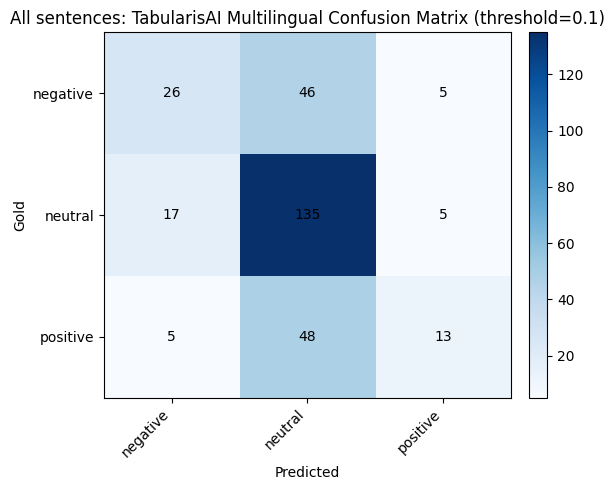

All sentences — ZombitX64 MultiSent E5 Pro (threshold=0.8)


predicted,negative,neutral,positive
gold,,,
negative,1,43,33
neutral,5,27,125
positive,0,33,33


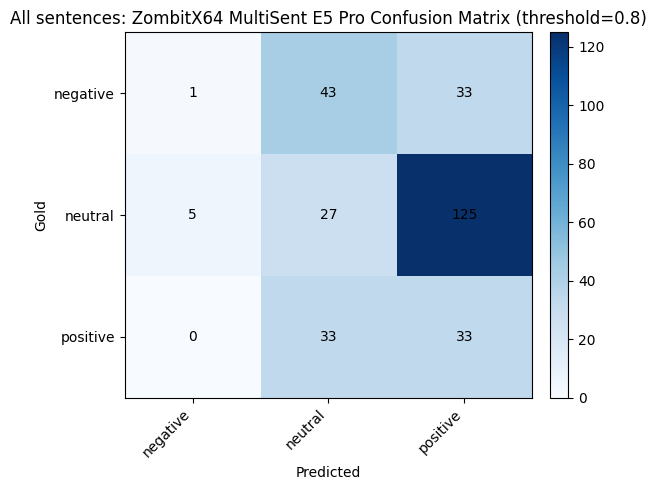

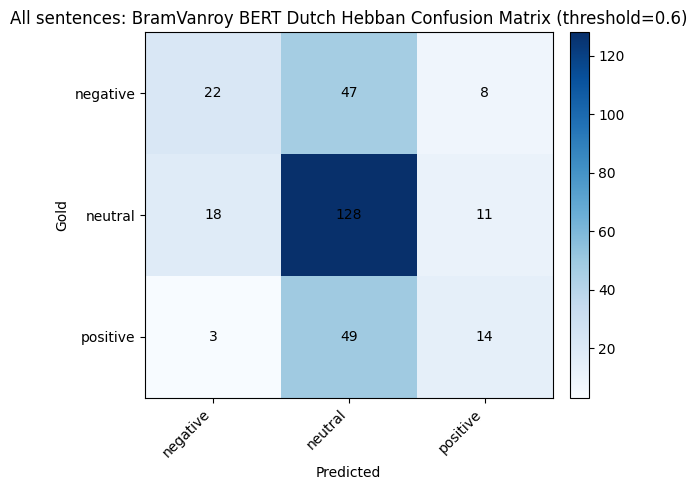

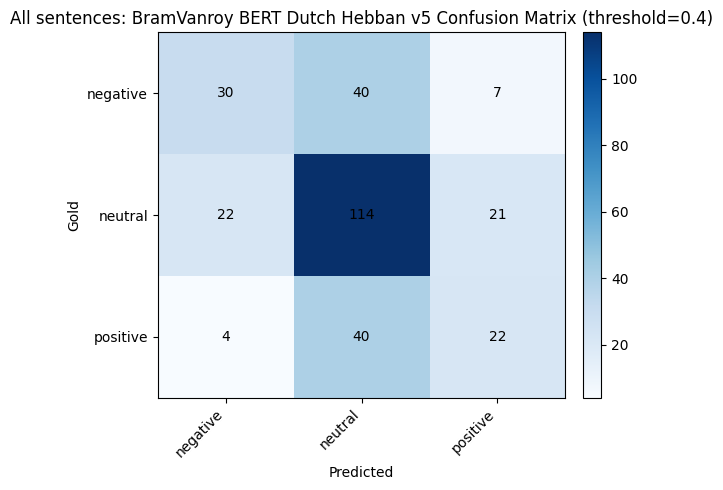

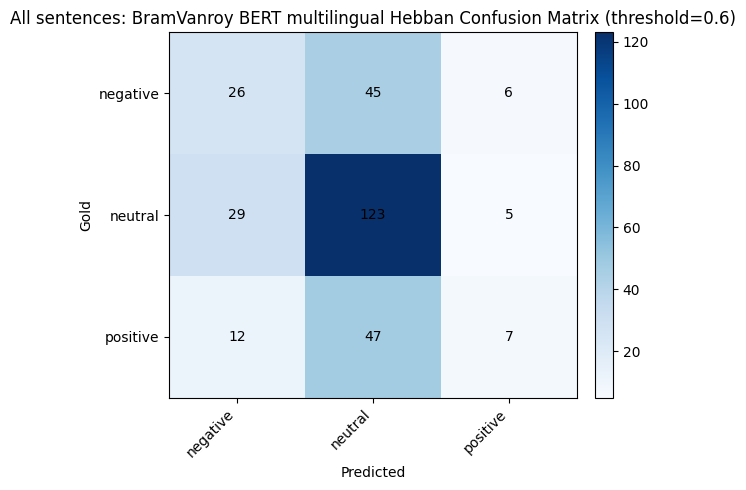

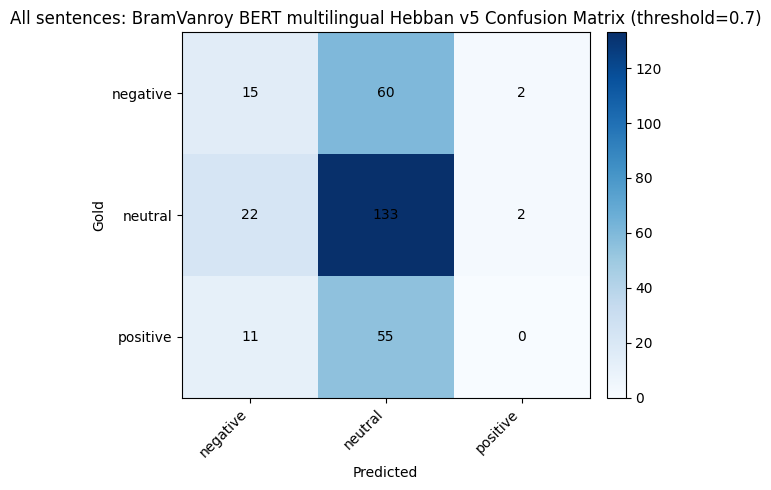

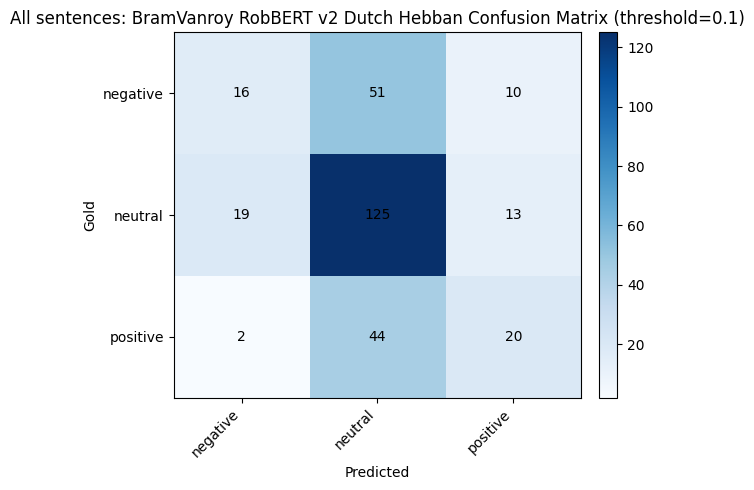

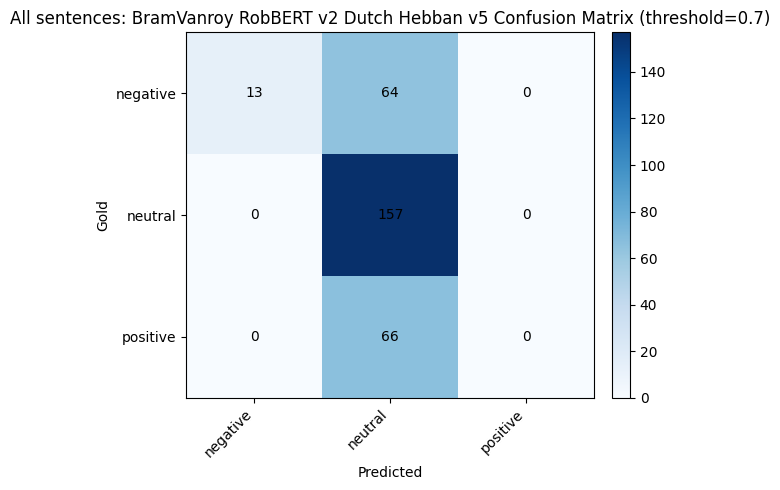

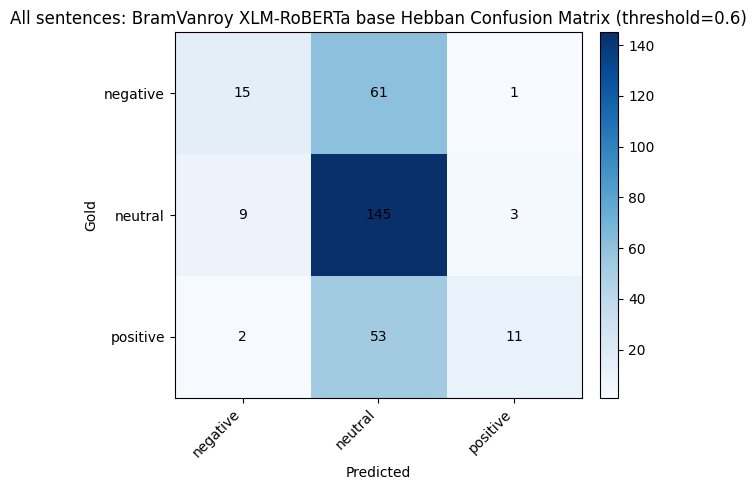

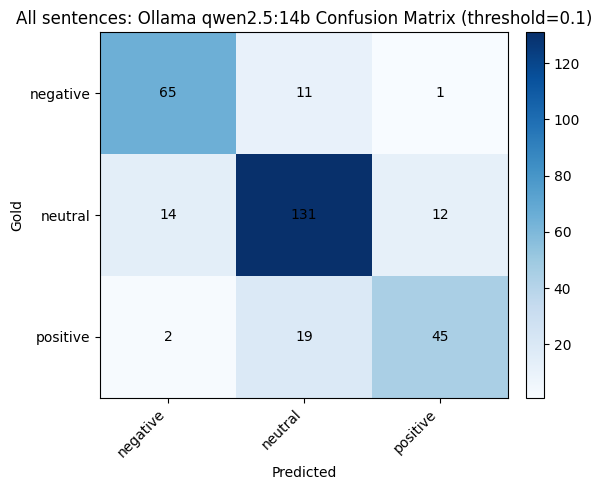

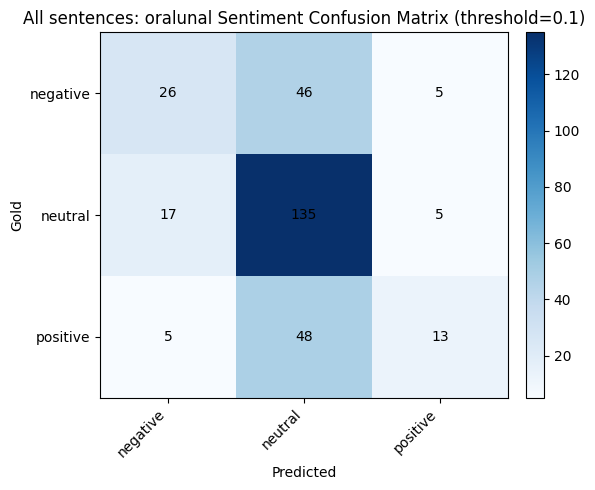

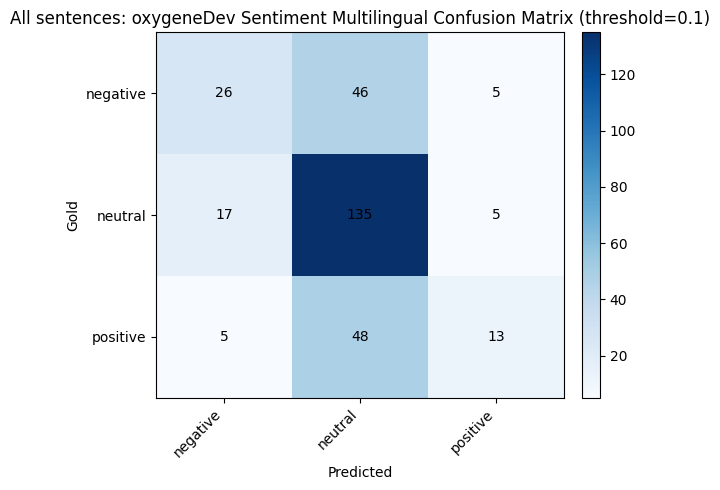

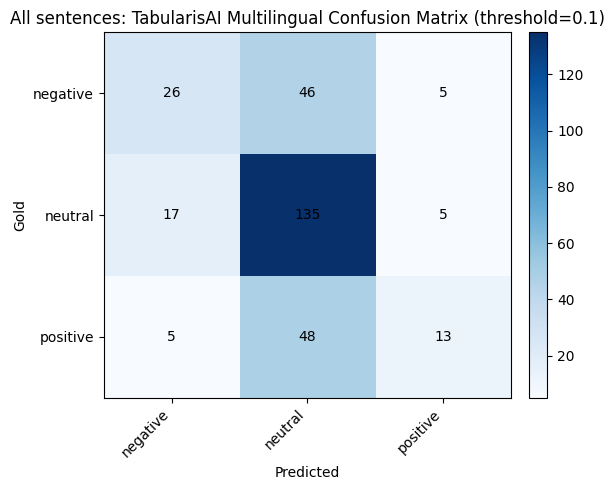

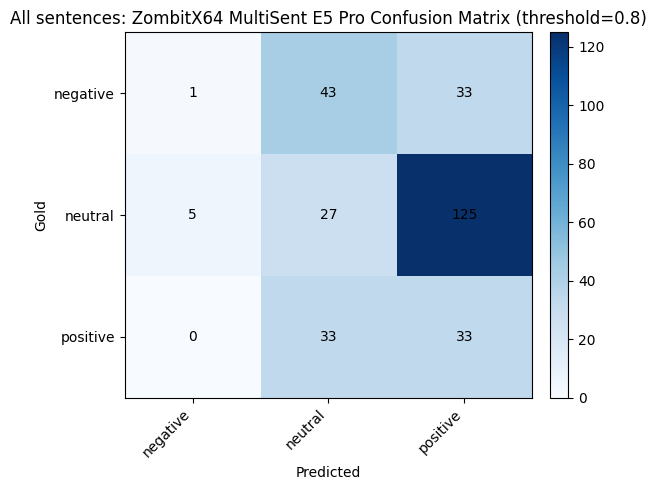

Saved thresholded confusion matrices for 12 files to /Users/Yannick/dev/geothermal_text_mining/annotation/sentiment_model_assessment/confusion_matrices


In [65]:
if best_thresholds.empty:
    raise ValueError("No best threshold values were found. Ensure the threshold analysis cell is executed first.")


def confusion_matrix_df(gold, pred, labels=SENTIMENTS):
    matrix = pd.crosstab(
        gold,
        pred,
        rownames=["gold"],
        colnames=["predicted"],
        dropna=False,
    )
    return matrix.reindex(index=labels, columns=labels, fill_value=0)


def plot_confusion_matrix(matrix, title=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matrix, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, int(matrix.iat[i, j]), ha="center", va="center", color="black")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")
    if title:
        ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return fig


def adjusted_predictions(group, pred_col, conf_col, threshold):
    return apply_neutral_threshold(group[pred_col], group[conf_col], threshold)


for _, row in best_thresholds.iterrows():
    model = row["model"]
    model_display_name = row.get("model_display_name", model)
    threshold = row["threshold"]
    pred_col = f"{model}__sentiment"
    conf_col = f"{model}__confidence"
    matrix = confusion_matrix_df(
        merged["gold_sentiment"],
        adjusted_predictions(merged, pred_col, conf_col, threshold),
    )
    print(f"All sentences — {model_display_name} (threshold={threshold})")
    display(matrix)
    plot_confusion_matrix(matrix, title=f"All sentences: {model_display_name} Confusion Matrix (threshold={threshold})")

output_dir = STUDY_DIR / "confusion_matrices"
output_dir.mkdir(parents=True, exist_ok=True)

for _, row in best_thresholds.iterrows():
    model = row["model"]
    model_display_name = row.get("model_display_name", model)
    threshold = row["threshold"]
    pred_col = f"{model}__sentiment"
    conf_col = f"{model}__confidence"
    matrix = confusion_matrix_df(
        merged["gold_sentiment"],
        adjusted_predictions(merged, pred_col, conf_col, threshold),
    )
    csv_path = output_dir / f"all_sentences_{model}_threshold_{threshold}_confusion_matrix.csv"
    matrix.to_csv(csv_path)
    fig = plot_confusion_matrix(matrix, title=f"All sentences: {model_display_name} Confusion Matrix (threshold={threshold})")
    png_path = output_dir / f"all_sentences_{model}_threshold_{threshold}_confusion_matrix.png"
    fig.savefig(png_path, bbox_inches="tight")
    plt.close(fig)

print(f"Saved thresholded confusion matrices for {len(best_thresholds)} files to {output_dir}")

In [66]:
overlap = merged[merged["assignment_group"] == "overlap"].copy()
overlap_gold = overlap.pivot_table(
    index="sample_id",
    columns="annotator",
    values="gold_sentiment",
    aggfunc="first",
)
overlap_gold = overlap_gold.dropna().reset_index()
overlap_gold["annotator_agree"] = overlap_gold["Dekker"] == overlap_gold["Egberink"]
overlap_gold[["sample_id", "Dekker", "Egberink", "annotator_agree"]].head()

annotator,sample_id,Dekker,Egberink,annotator_agree
0,0c523fed9343801ac74afe7261c511fb478dd6e298dd2b...,neutral,neutral,True
1,0ee99c93a142b01cc8216c9249fa2c3168b339c7f5ea31...,negative,negative,True
2,0f39e17c42ffb6fe1eeea02e1f5c1a8985563d987bcba3...,positive,positive,True
3,145468ca17ba7665b00dcb93272cbf6dab4d2ca89fadf0...,neutral,positive,False
4,1e4e9c7a3b4d48fe5abdf7a63a1f05e10bf839d08a413c...,positive,positive,True


In [67]:
overlap_gold["annotator_agree"].mean() if len(overlap_gold) else None

np.float64(0.6666666666666666)

In [68]:
performance.to_csv(STUDY_DIR / "model_performance_from_notebook.csv", index=False)
performance

,annotator,model,model_display_name,n,accuracy,macro_f1
7,Dekker,ollama_qwen2_5_7b,Ollama qwen2.5:14b,150,0.813333,0.789490
10,Dekker,tabularisai_multilingual,TabularisAI Multilingual,150,0.620000,0.457884
8,Dekker,oralunal_sentiment,oralunal Sentiment,150,0.620000,0.457884
9,Dekker,oxygene_dev_sentiment_multilingual,oxygeneDev Sentiment Multilingual,150,0.620000,0.457884
1,Dekker,bramvanroy_bert_base_dutch_cased_hebban_reviews,BramVanroy BERT Dutch Hebban,150,0.586667,0.483025
5,Dekker,bramvanroy_robbert_v2_dutch_base_hebban_reviews,BramVanroy RobBERT v2 Dutch Hebban,150,0.566667,0.399310
4,Dekker,bramvanroy_robbert_v2_dutch_base_hebban_reviews5,BramVanroy RobBERT v2 Dutch Hebban v5,150,0.493333,0.405693
6,Dekker,bramvanroy_xlm_roberta_base_hebban_reviews,BramVanroy XLM-RoBERTa base Hebban,150,0.466667,0.448675
2,Dekker,bramvanroy_bert_base_multilingual_cased_hebban...,BramVanroy BERT multilingual Hebban v5,150,0.426667,0.418282
3,Dekker,bramvanroy_bert_base_multilingual_cased_hebban...,BramVanroy BERT multilingual Hebban,150,0.426667,0.391173
